In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_emg_file(
    csv_path,
    time_col=None,
    start_time=None,
    end_time=None,
    rel_time_col=None,
    start_rel=None,
    end_rel=None,
):
    """
    Plot EMG channels from a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file.
    time_col : str or None
        Absolute time column, e.g. 'timestamp_la' or 'timestamp'.
        If None, auto-detects from ['timestamp_la', 'timestamp'].
    start_time, end_time : str or datetime-like or None
        Absolute time window.
    rel_time_col : str or None
        Relative time column, e.g. 'host_rel_s' or 'device_s'.
    start_rel, end_rel : float or None
        Relative time window.
    """
    df = pd.read_csv(csv_path)

    # auto-detect absolute time column
    if time_col is None:
        for c in ["timestamp_la", "timestamp"]:
            if c in df.columns:
                time_col = c
                break

    # choose x-axis
    use_abs_time = time_col is not None and time_col in df.columns
    use_rel_time = rel_time_col is not None and rel_time_col in df.columns

    if use_abs_time:
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
        df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

        if start_time is not None:
            df = df[df[time_col] >= pd.to_datetime(start_time)]
        if end_time is not None:
            df = df[df[time_col] <= pd.to_datetime(end_time)]

        x = df[time_col]
        x_label = time_col

    elif use_rel_time:
        df[rel_time_col] = pd.to_numeric(df[rel_time_col], errors="coerce")
        df = df.dropna(subset=[rel_time_col]).sort_values(rel_time_col).reset_index(drop=True)

        if start_rel is not None:
            df = df[df[rel_time_col] >= float(start_rel)]
        if end_rel is not None:
            df = df[df[rel_time_col] <= float(end_rel)]

        x = df[rel_time_col]
        x_label = rel_time_col

    else:
        raise KeyError(
            f"Could not find a usable time column. Columns are: {list(df.columns)}"
        )

    if df.empty:
        print("No data found in the selected range.")
        return df

    emg_cols = [c for c in ["emg0", "emg1", "emg2", "emg3"] if c in df.columns]
    if not emg_cols:
        raise KeyError("No EMG columns found among ['emg0', 'emg1', 'emg2', 'emg3'].")

    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(8, 6), sharex=True)
    if len(emg_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, emg_cols):
        y = pd.to_numeric(df[col], errors="coerce")
        ax.plot(x, y, linewidth=1)
        # ax.set_title(col)
        ax.grid(True, alpha=0.3)
        # ax.set_ylim(1000, 3000)

    axes[-1].set_xlabel(x_label)
    plt.tight_layout()
    plt.show()

    print(f"Rows plotted: {len(df)}")
    if use_abs_time:
        print(f"Time range: {df[time_col].iloc[0]} -> {df[time_col].iloc[-1]}")
    else:
        print(f"Range: {df[rel_time_col].iloc[0]} -> {df[rel_time_col].iloc[-1]}")

    return df

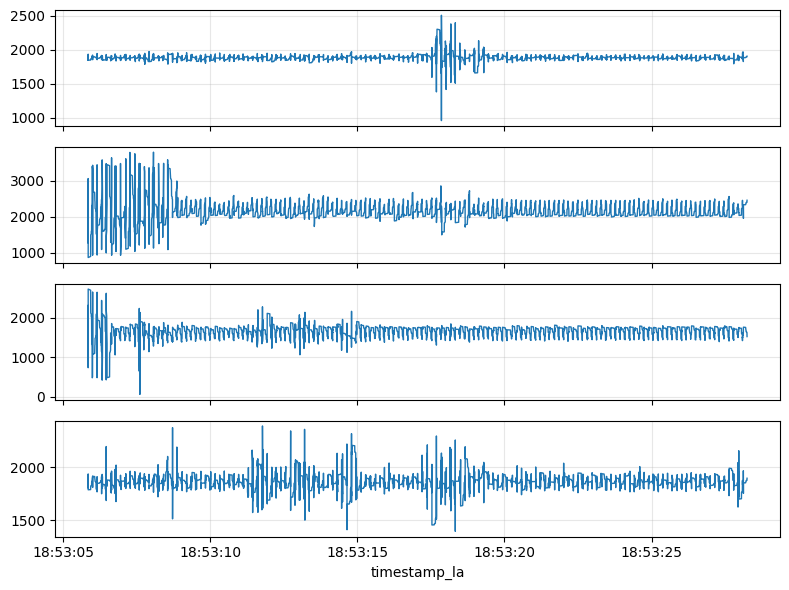

Rows plotted: 9922
Time range: 2026-04-09 18:53:05.835361 -> 2026-04-09 18:53:28.246752


,host_time_s,host_rel_s,device_us,device_s,trial_id,label,mark,modality,emg0,emg1,emg2,emg3,cap_pf,fsr_raw,relay_on,raw_line,timestamp_la
36121,1.775786e+09,81.922023,1.997085e+09,1997.084864,5,pick_up,NaN,EMG,1847.000000,1277.000000,2315.000000,1807.000000,NaN,NaN,NaN,"E,1997084864,1847,1277,2315,1807",2026-04-09 18:53:05.835361
36122,1.775786e+09,81.922120,1.997086e+09,1997.085864,5,pick_up,NaN,EMG,1863.000000,1503.000000,2104.000000,1821.000000,NaN,NaN,NaN,"E,1997085864,1863,1503,2104,1821",2026-04-09 18:53:05.835458
36123,1.775786e+09,81.922137,1.997087e+09,1997.086864,5,pick_up,NaN,EMG,1881.000000,1571.000000,2018.000000,1847.000000,NaN,NaN,NaN,"E,1997086864,1881,1571,2018,1847",2026-04-09 18:53:05.835474
36124,1.775786e+09,81.922151,1.997088e+09,1997.087864,5,pick_up,NaN,EMG,1871.000000,1708.000000,1895.000000,1859.000000,NaN,NaN,NaN,"E,1997087864,1871,1708,1895,1859",2026-04-09 18:53:05.835489
36125,1.775786e+09,81.931903,1.997089e+09,1997.088864,5,pick_up,NaN,EMG,1869.000000,1817.000000,1809.000000,1851.000000,NaN,NaN,NaN,"E,1997088864,1869,1817,1809,1851",2026-04-09 18:53:05.845241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46038,1.775786e+09,104.333175,2.019515e+09,2019.514938,7,pick_up,NaN,EMG,1901.058824,2445.588235,1553.470588,1891.470588,NaN,NaN,NaN,"E,2019514938,2024,4095,419,1826",2026-04-09 18:53:28.246512
46039,1.775786e+09,104.333224,2.019516e+09,2019.515938,7,pick_up,NaN,EMG,1901.666667,2449.000000,1547.000000,1892.666667,NaN,NaN,NaN,"E,2019515938,2001,4095,496,1759",2026-04-09 18:53:28.246562
46040,1.775786e+09,104.333384,2.019517e+09,2019.516938,7,pick_up,NaN,EMG,1902.274510,2452.411765,1540.529412,1893.862745,NaN,NaN,NaN,"E,2019516938,1957,3997,632,1815",2026-04-09 18:53:28.246721
46041,1.775786e+09,104.333400,2.019518e+09,2019.517938,7,pick_up,NaN,EMG,1902.882353,2455.823529,1534.058824,1895.058824,NaN,NaN,NaN,"E,2019517938,1901,3768,681,1864",2026-04-09 18:53:28.246737


In [38]:
plot_emg_file(
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/1-3_LAtime_EMG_clean.csv",
    time_col="timestamp_la",
    start_time="2026-04-09 18:53:05.835",
    end_time="2026-04-09 18:53:28.247",
)

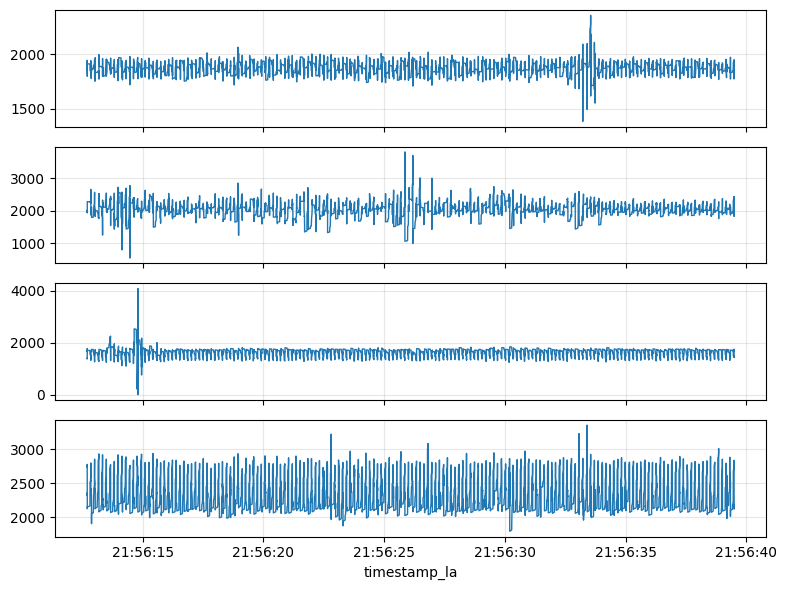

Rows plotted: 11882
Time range: 2026-04-09 21:56:12.705799 -> 2026-04-09 21:56:39.491597


,host_time_s,host_rel_s,device_us,device_s,trial_id,label,mark,emg0,emg1,emg2,emg3,cap_pf,angle_deg,relay_on,src,timestamp_la
20327,1.775797e+09,46.110180,901139059,901.139059,2,pick_up,NaN,1854.686275,1949.254902,1402.568627,2734.294118,0.0,NaN,0.0,EMG,2026-04-09 21:56:12.705799
20328,1.775797e+09,46.110207,901140059,901.140059,2,pick_up,NaN,1856.764706,1947.941176,1396.176471,2744.470588,0.0,NaN,0.0,EMG,2026-04-09 21:56:12.705826
20329,1.775797e+09,46.110224,901141059,901.141059,2,pick_up,NaN,1858.843137,1946.627451,1389.784314,2754.647059,0.0,NaN,0.0,EMG,2026-04-09 21:56:12.705842
20330,1.775797e+09,46.110237,901142059,901.142059,2,pick_up,NaN,1860.921569,1945.313725,1383.392157,2764.823529,0.0,NaN,0.0,EMG,2026-04-09 21:56:12.705856
20331,1.775797e+09,46.110250,901143059,901.143059,2,pick_up,NaN,1863.000000,1944.000000,1377.000000,2775.000000,0.0,NaN,0.0,EMG,2026-04-09 21:56:12.705868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32204,1.775797e+09,72.895940,927942305,927.942305,3,pick_up,NaN,1916.000000,2323.000000,1669.000000,2321.000000,0.0,NaN,0.0,EMG,2026-04-09 21:56:39.491559
32205,1.775797e+09,72.895950,927943305,927.943305,3,pick_up,NaN,1928.000000,2181.000000,1725.000000,2119.000000,0.0,NaN,0.0,EMG,2026-04-09 21:56:39.491569
32206,1.775797e+09,72.895959,927944305,927.944305,3,pick_up,NaN,1941.000000,2075.000000,1669.000000,2199.000000,0.0,NaN,0.0,EMG,2026-04-09 21:56:39.491578
32207,1.775797e+09,72.895969,927945305,927.945305,3,pick_up,NaN,1888.000000,1879.000000,1755.000000,2129.000000,0.0,NaN,0.0,EMG,2026-04-09 21:56:39.491588


In [ ]:
plot_emg_file(
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/2-10_LAtime_EMG_clean.csv",
    time_col="timestamp_la",
    start_time="2026-04-09 21:56:12.705",
    end_time="2026-04-09 21:56:39.602",
)

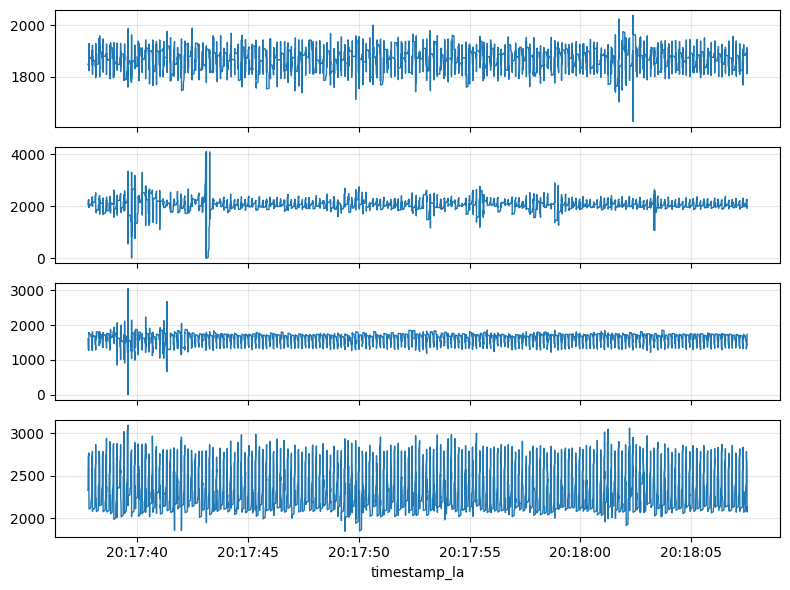

Rows plotted: 13191
Time range: 2026-04-09 20:17:37.793438 -> 2026-04-09 20:18:07.510437


,host_time_s,host_rel_s,device_us,device_s,trial_id,label,mark,emg0,emg1,emg2,emg3,cap_pf,angle_deg,relay_on,src,timestamp_la
62656,1.775791e+09,141.874989,1465116353,1465.116353,5,pick_up,NaN,1847.745098,2058.039216,1599.352941,2329.784314,0.0,NaN,0.0,EMG,2026-04-09 20:17:37.793438
62657,1.775791e+09,141.875056,1465117352,1465.117352,5,pick_up,NaN,1847.666667,2063.666667,1590.000000,2342.333333,0.0,NaN,0.0,EMG,2026-04-09 20:17:37.793505
62658,1.775791e+09,141.883371,1465118352,1465.118352,5,pick_up,NaN,1847.588235,2069.294118,1580.647059,2354.882353,0.0,NaN,0.0,EMG,2026-04-09 20:17:37.801820
62659,1.775791e+09,141.883428,1465119352,1465.119352,5,pick_up,NaN,1847.509804,2074.921569,1571.294118,2367.431373,0.0,NaN,0.0,EMG,2026-04-09 20:17:37.801877
62660,1.775791e+09,141.883446,1465120353,1465.120353,5,pick_up,NaN,1847.431373,2080.549020,1561.941176,2379.980392,0.0,NaN,0.0,EMG,2026-04-09 20:17:37.801896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75842,1.775791e+09,171.591654,1494837440,1494.837440,5,rest,NaN,1856.000000,1975.000000,1671.000000,2169.000000,0.0,NaN,0.0,EMG,2026-04-09 20:18:07.510103
75843,1.775791e+09,171.591881,1494838440,1494.838440,5,rest,NaN,1856.000000,1995.000000,1727.000000,2157.000000,0.0,NaN,0.0,EMG,2026-04-09 20:18:07.510330
75844,1.775791e+09,171.591894,1494839440,1494.839440,5,rest,NaN,1883.000000,2001.000000,1697.000000,2093.000000,0.0,NaN,0.0,EMG,2026-04-09 20:18:07.510344
75845,1.775791e+09,171.591904,1494840440,1494.840440,5,rest,NaN,1893.000000,2001.000000,1732.000000,2073.000000,0.0,NaN,0.0,EMG,2026-04-09 20:18:07.510354


In [36]:
plot_emg_file(
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/3-6_LAtime_EMG_clean.csv",
    time_col="timestamp_la",
    start_time="2026-04-09 20:17:37.793",
    end_time="2026-04-09 20:18:07.591",
)

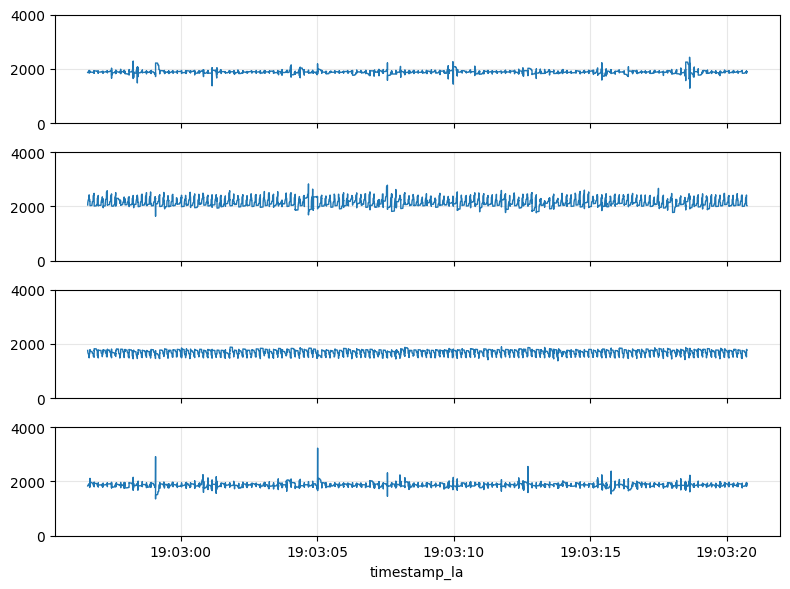

Rows plotted: 10721
Time range: 2026-04-09 19:02:56.595335 -> 2026-04-09 19:03:20.741767


,host_time_s,host_rel_s,device_us,device_s,label_id,label_cm,emg0,emg1,emg2,emg3,cap_pf,src,timestamp_la
55844,1.775787e+09,126.671592,2587848900,2587.848900,0,0,1864.784314,2047.470588,1755.941176,1829.549020,0.0,EMG,2026-04-09 19:02:56.595335
55845,1.775787e+09,126.671668,2587849900,2587.849900,0,0,1865.568627,2054.941176,1750.882353,1831.098039,0.0,EMG,2026-04-09 19:02:56.595412
55846,1.775787e+09,126.671685,2587850900,2587.850900,0,0,1866.352941,2062.411765,1745.823529,1832.647059,0.0,EMG,2026-04-09 19:02:56.595428
55847,1.775787e+09,126.671698,2587851900,2587.851900,0,0,1867.137255,2069.882353,1740.764706,1834.196078,0.0,EMG,2026-04-09 19:02:56.595442
55848,1.775787e+09,126.671896,2587852900,2587.852900,0,0,1867.921569,2077.352941,1735.705882,1835.745098,0.0,EMG,2026-04-09 19:02:56.595639
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66560,1.775787e+09,150.798427,2611971629,2611.971629,7,35,1891.000000,2083.000000,1752.000000,1909.000000,0.0,EMG,2026-04-09 19:03:20.722171
66561,1.775787e+09,150.798633,2611972629,2611.972629,7,35,1915.000000,2064.000000,1771.000000,1897.000000,0.0,EMG,2026-04-09 19:03:20.722377
66562,1.775787e+09,150.798707,2611973629,2611.973629,7,35,1917.000000,2039.000000,1792.000000,1959.000000,0.0,EMG,2026-04-09 19:03:20.722450
66563,1.775787e+09,150.800291,2611974629,2611.974629,7,35,1893.000000,2034.000000,1795.000000,1896.000000,0.0,EMG,2026-04-09 19:03:20.724035


In [32]:
plot_emg_file(
    "/Users/mmz/Rehab_sensing/260113_data_collection_final/260409_data/clean_emg/4-3_LAtime_EMG_clean.csv",
    time_col="timestamp_la",
    start_time="2026-04-09 19:02:56.595",
    end_time="2026-04-09 19:03:20.805",
)